In [14]:
colonnes_texte = train.select_dtypes(include='object').columns.tolist()
print("Colonnes texte :", colonnes_texte)

Colonnes texte : ['label']


C:\Users\Sidney\AppData\Local\Temp\ipykernel_26500\3450997964.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colonnes_texte = train.select_dtypes(include='object').columns.tolist()


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Normalisation terminée ✓")
print("Moyenne X_train (doit être ~0) :", X_train_scaled.mean().round(3))

Normalisation terminée ✓
Moyenne X_train (doit être ~0) : 0.0


In [16]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.47,
    random_state=42
)
model.fit(X_train_scaled)
print("Modèle entraîné ✓")

Modèle entraîné ✓


In [17]:
raw_preds = model.predict(X_test_scaled)
scores    = model.score_samples(X_test_scaled)
y_pred    = (raw_preds == -1).astype(int)

print("Prédictions terminées ✓")
print("Attaques détectées :", y_pred.sum())

Prédictions terminées ✓
Attaques détectées : 12739


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ['protocol_type', 'service', 'flag']:
    train[col] = le.fit_transform(train[col])
    test[col]  = le.transform(test[col])

print("Encodage terminé ✓")

Encodage terminé ✓


In [12]:
features = [c for c in train.columns if c not in ['label', 'difficulty', 'is_attack']]

X_train = train[features].values
y_train = train['is_attack'].values

X_test = test[features].values
y_test = test['is_attack'].values

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

X_train : (125973, 41)
X_test  : (22544, 41)


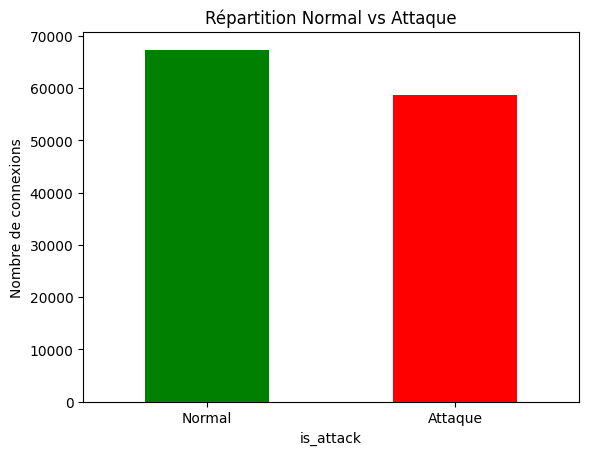

In [8]:
train['is_attack'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Répartition Normal vs Attaque')
plt.xticks([0, 1], ['Normal', 'Attaque'], rotation=0)
plt.ylabel('Nombre de connexions')
plt.show()

In [9]:
print("Valeurs manquantes :\n", train.isnull().sum().sum())
print("Types de colonnes :\n", train.dtypes.value_counts())

Valeurs manquantes :
 0
Types de colonnes :
 int64      25
float64    15
str         4
Name: count, dtype: int64


In [4]:
train = pd.read_csv('../data/KDDTrain+.csv', names=columns)
test  = pd.read_csv('../data/KDDTest+.csv',  names=columns)

print("Train :", train.shape)
print("Test  :", test.shape)

Train : (125973, 43)
Test  : (22544, 43)


In [5]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [6]:
print(train['label'].value_counts())

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [7]:
train['is_attack'] = train['label'].apply(lambda x: 0 if x == 'normal' else 1)
test['is_attack']  = test['label'].apply(lambda x: 0 if x == 'normal' else 1)

print("Attaques (train) :", train['is_attack'].sum())
print("Normal   (train) :", (train['is_attack'] == 0).sum())

Attaques (train) : 58630
Normal   (train) : 67343


In [3]:
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred, target_names=['Normal', 'Attaque']))

              precision    recall  f1-score   support

      Normal       0.75      0.76      0.76      9711
     Attaque       0.82      0.81      0.82     12833

    accuracy                           0.79     22544
   macro avg       0.79      0.79      0.79     22544
weighted avg       0.79      0.79      0.79     22544



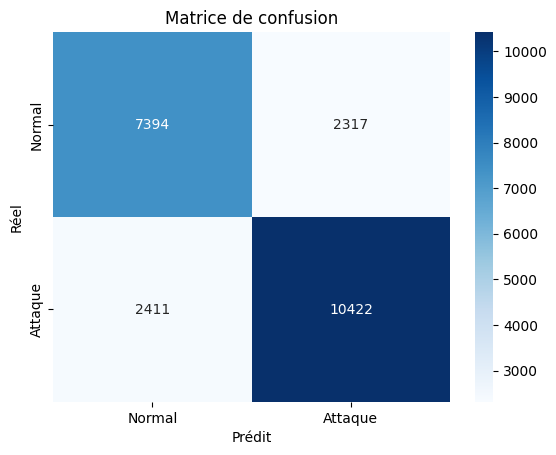

In [19]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attaque'],
            yticklabels=['Normal', 'Attaque'])
plt.title('Matrice de confusion')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.show()

In [20]:
auc = roc_auc_score(y_test, -scores)
print(f"AUC-ROC : {auc:.4f}")

AUC-ROC : 0.8820


In [21]:
import joblib

joblib.dump(model, '../detection/model_isolation_forest.pkl')
joblib.dump(scaler, '../detection/scaler.pkl')
print("Modèle et scaler sauvegardés ✓")

Modèle et scaler sauvegardés ✓


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
print("Random Forest entraîné ✓")

Random Forest entraîné ✓


In [23]:
y_pred_rf = rf_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Attaque']))

              precision    recall  f1-score   support

      Normal       0.66      0.97      0.78      9711
     Attaque       0.97      0.62      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.83      0.77      0.77     22544



In [25]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_train_scaled, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model2.fit(X_train2, y_train2)

y_pred2 = rf_model2.predict(X_test2)
print(classification_report(y_test2, y_pred2, target_names=['Normal', 'Attaque']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
     Attaque       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [26]:
joblib.dump(rf_model2, '../detection/model_random_forest.pkl')
print("Meilleur modèle sauvegardé ✓")

Meilleur modèle sauvegardé ✓
